In [71]:
import os
import re
import glob
import numpy as np
import pandas as pd
import scipy.io as sio
import spikeinterface.extractors as se
import spikeinterface as si
import spikeinterface.sorters as ss
import spikeinterface.postprocessing as spost
import spikeinterface.qualitymetrics as sqm
from pathlib import Path
import matplotlib.pyplot as plt
import json
from typing import List, Tuple
from scipy.stats import pearsonr
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
from probeinterface import write_probeinterface, read_probeinterface, Probe
from scipy.io import loadmat

from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Rectangle

In [40]:
CLUSTER_INFO_FILENAME = "cluster_info.tsv"

SPIKE_CLUSTERS_FILENAME = "spike_clusters.npy"
SPIKE_TIMES_FILENAME = "spike_times.npy"




def load_cluster_info(phy_dir: str) -> pd.DataFrame:
    """读取 phy_folder_for_kilosort/cluster_info.tsv 为 DataFrame。
    该表包含所有需要的 cluster 级指标。
    如果cluster_info.tsv不存在，则尝试从其他文件构建基本信息。
    同时计算并添加mean_waveform信息。
    """
    path = os.path.join(phy_dir, CLUSTER_INFO_FILENAME)
    
    if os.path.exists(path):
        df = pd.read_csv(path, sep='\t')
        # 标准化主键列名
        if 'cluster_id' not in df.columns:
            raise ValueError(f"{path} 中缺少 cluster_id 列")
    else:
        print(f"警告: {path} 不存在，尝试从其他文件构建cluster信息")
        
        # 尝试从cluster_group.tsv构建基本信息
        cluster_group_path = os.path.join(phy_dir, "cluster_group.tsv")
        if os.path.exists(cluster_group_path):
            df = pd.read_csv(cluster_group_path, sep='\t')
            if 'cluster_id' not in df.columns:
                raise ValueError(f"{cluster_group_path} 中缺少 cluster_id 列")
        else:
            # 如果都没有，从spike_clusters.npy中提取唯一的cluster_id
            spike_clusters_path = os.path.join(phy_dir, SPIKE_CLUSTERS_FILENAME)
            if os.path.exists(spike_clusters_path):
                spike_clusters = np.load(spike_clusters_path)
                unique_clusters = np.unique(spike_clusters)
                df = pd.DataFrame({
                    'cluster_id': unique_clusters,
                    'group': 'unsorted'  # 默认分组
                })
            else:
                raise ValueError(f"无法找到任何cluster信息文件: {phy_dir}")
    
    # 如果cluster_info.tsv中没有si_unit_id，尝试从cluster_si_unit_ids.tsv读取
    if 'si_unit_id' not in df.columns:
        si_unit_id_path = os.path.join(phy_dir, "cluster_si_unit_ids.tsv")
        if os.path.exists(si_unit_id_path):
            si_unit_df = pd.read_csv(si_unit_id_path, sep='\t')
            df = df.merge(si_unit_df[['cluster_id', 'si_unit_id']], on='cluster_id', how='left')
        else:
            # 如果没有si_unit_id，假设cluster_id就是si_unit_id（对于旧格式）
            df['si_unit_id'] = df['cluster_id']
    
    # 计算mean_waveform并展开为多列添加到DataFrame
    cluster_waveform_data = compute_mean_waveform(phy_dir)
    if cluster_waveform_data:
        # 确定waveform的长度（通常是90个时间点）
        waveform_length = None
        for cluster_data in cluster_waveform_data.values():
            if cluster_data['waveform'] is not None:
                waveform_length = len(cluster_data['waveform'])
                break
        
        if waveform_length is not None:
            # 添加位置信息和best_channels列
            df['position_1'] = np.nan
            df['position_2'] = np.nan
            df['best_channels'] = None
            df['best_channel'] = np.nan
            
            # 创建waveform列名
            waveform_columns = [f'mean_waveform_{i}' for i in range(waveform_length)]
            
            # 为每个cluster创建waveform数据
            waveform_data = {}
            for idx, row in df.iterrows():
                cluster_id = row['cluster_id']
                si_unit_id = row.get('si_unit_id', cluster_id)  # 使用si_unit_id而不是cluster_id
                
                # 检查si_unit_id是否为NaN
                if pd.isna(si_unit_id):
                    si_unit_id = cluster_id  # 如果si_unit_id是NaN，回退到cluster_id
                else:
                    si_unit_id = int(si_unit_id)
                
                # 使用si_unit_id（template索引）来查找waveform数据
                if si_unit_id in cluster_waveform_data:
                    cluster_data = cluster_waveform_data[si_unit_id]
                    
                    # 添加位置信息和best_channels
                    pos_x, pos_y = cluster_data['position']
                    df.loc[idx, 'position_1'] = pos_x
                    df.loc[idx, 'position_2'] = pos_y
                    df.loc[idx, 'best_channels'] = str(cluster_data['channels'])
                    
                    # 计算best_channel：从best_channels中找到幅度绝对值最大的通道
                    channels = cluster_data['channels']
                    amplitudes = cluster_data['amplitudes']
                    if len(channels) > 0 and len(amplitudes) > 0:
                        # 找到幅度最大的通道索引
                        max_amp_idx = np.argmax(np.abs(amplitudes))
                        best_channel = channels[max_amp_idx]
                        df.loc[idx, 'best_channel'] = int(best_channel)
                    
                    waveform = cluster_data['waveform']
                    # 确保waveform长度一致
                    if waveform is not None and len(waveform) > 0:
                        if len(waveform) == waveform_length:
                            waveform_data[cluster_id] = waveform
                        else:
                            # 如果长度不匹配，用NaN填充或截断
                            padded_waveform = np.full(waveform_length, np.nan)
                            padded_waveform[:min(len(waveform), waveform_length)] = waveform[:min(len(waveform), waveform_length)]
                            waveform_data[cluster_id] = padded_waveform
                    else:
                        waveform_data[cluster_id] = np.full(waveform_length, np.nan)
                else:
                    # 没有数据的cluster用NaN填充
                    waveform_data[cluster_id] = np.full(waveform_length, np.nan)
            
            # 将waveform数据转换为DataFrame并合并
            waveform_df = pd.DataFrame.from_dict(waveform_data, orient='index', columns=waveform_columns)
            waveform_df.index.name = 'cluster_id'
            waveform_df = waveform_df.reset_index()
            
            df = df.merge(waveform_df, on='cluster_id', how='left')
        else:
            print("警告: 无法确定waveform长度")
    else:
        print("警告: 无法计算cluster数据")
        # 添加空的位置列和best_channels列
        df['position_1'] = np.nan
        df['position_2'] = np.nan
        df['best_channels'] = None
        df['best_channel'] = np.nan
    
    return df


def load_spike_level(phy_dir: str) -> pd.DataFrame:
    """读取 spike 层面的 numpy 文件并返回 DataFrame: [cluster, time]
    time 使用原始采样点，不做单位转换。
    """
    spike_clusters = np.load(os.path.join(phy_dir, SPIKE_CLUSTERS_FILENAME))
    spike_times = np.load(os.path.join(phy_dir, SPIKE_TIMES_FILENAME))
    # 展平为一维
    spike_clusters = np.asarray(spike_clusters).reshape(-1)
    spike_times = np.asarray(spike_times).reshape(-1)
    if spike_clusters.shape[0] != spike_times.shape[0]:
        raise ValueError(f"spike_clusters 与 spike_times 行数不一致: {phy_dir}")
    df = pd.DataFrame({
        'cluster_id': spike_clusters.astype(int),
        'time': spike_times.astype(int),
    })
    return df


def compute_mean_waveform(phy_dir: str) -> dict:
    """根据probe信息、template_ind.npy和templates.npy计算每个cluster的位置和波形
    
    Returns:
        dict: {cluster_id: {'position': (x, y), 'waveform': waveform_array}}
    """
    templates_path = os.path.join(phy_dir, "templates.npy")
    template_ind_path = os.path.join(phy_dir, "template_ind.npy")
    
    if not all(os.path.exists(p) for p in [templates_path, template_ind_path]):
        print("警告: 缺少templates.npy或template_ind.npy文件")
        return {}
    
    # 加载数据
    templates = np.load(templates_path)  # shape: (n_templates, n_timepoints, n_channels)
    template_ind = np.load(template_ind_path)  # shape: (n_templates, n_channels)
    
    # 使用全局probe信息
    global probe
    
    # 获取probe的通道位置信息
    channel_positions = {}
    for i in range(30):
        x, y = probe.to_dataframe()['x'][i], probe.to_dataframe()['y'][i]
        # 处理浮点数contact_id
        channel_id = int(float(i))
        channel_positions[channel_id] = [x, y]
    
    cluster_results = {}
    
    # 处理每个cluster
    for cluster_id in range(templates.shape[0]):
        template = templates[cluster_id]  # shape: (n_timepoints, n_channels)
        template_channels = template_ind[cluster_id]  # shape: (n_channels,)
        
        # 过滤掉-1的通道
        valid_channels = template_channels[template_channels != -1]
        if len(valid_channels) == 0:
            continue
            
        # 获取有效通道的波形数据
        valid_template = template[:, template_channels != -1]  # shape: (n_timepoints, n_valid_channels)
        
        # 计算每个通道的波形幅度（使用RMS）
        channel_amplitudes = np.sqrt(np.mean(valid_template**2, axis=0))
        
        # 根据通道位置和波形幅度计算cluster位置
        total_amplitude = 0
        weighted_x = 0
        weighted_y = 0
        
        for i, channel_id in enumerate(valid_channels):
            channel_id_int = int(float(channel_id))
            if channel_id_int in channel_positions:
                x, y = channel_positions[channel_id_int]
                amplitude = channel_amplitudes[i]
                
                weighted_x += x * amplitude
                weighted_y += y * amplitude
                total_amplitude += amplitude
        
        if total_amplitude > 0:
            cluster_x = weighted_x / total_amplitude
            cluster_y = weighted_y / total_amplitude
        else:
            cluster_x, cluster_y = 0, 0
        
        # 根据cluster位置反推波形大小
        # 计算到每个通道的距离
        distances = []
        for channel_id in valid_channels:
            channel_id_int = int(float(channel_id))
            if channel_id_int in channel_positions:
                x, y = channel_positions[channel_id_int]
                distance = np.sqrt((cluster_x - x)**2 + (cluster_y - y)**2)
                distances.append(distance)
            else:
                distances.append(float('inf'))
        
        # 使用IDW (Inverse Distance Weighting) 计算合成波形
        if len(distances) > 0 and not all(d == float('inf') for d in distances):
            # 避免除零
            distances = np.array(distances)
            distances[distances == 0] = 1e-6
            
            # 计算权重 (power=2)
            weights = 1 / (distances ** 2)
            weights = weights / np.sum(weights)
            
            # 合成波形
            synthesized_waveform = np.zeros(valid_template.shape[0])
            for t in range(valid_template.shape[0]):
                synthesized_waveform[t] = np.dot(valid_template[t, :], weights)
        else:
            # 如果无法计算距离，使用平均波形
            synthesized_waveform = np.mean(valid_template, axis=1)
        
        cluster_results[cluster_id] = {
            'position': (cluster_x, cluster_y),
            'waveform': synthesized_waveform,
            'channels': valid_channels.tolist(),
            'amplitudes': channel_amplitudes.tolist()
        }
    
    return cluster_results



In [41]:
probe = read_probeinterface('/media/ubuntu/sda/data/probe.json')


In [42]:
ROOT_SORT_DIR = f'/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/092422/phy_folder_for_kilosort'
cluster_inf = load_cluster_info(phy_dir=ROOT_SORT_DIR)
spike_inf = load_spike_level(phy_dir=ROOT_SORT_DIR)

cluster_inf = cluster_inf[cluster_inf['group'] == 'good']
spike_inf = spike_inf[spike_inf['cluster_id'].isin(cluster_inf['cluster_id'].values)]

# 根据cluster_id从cluster_inf中获取best_channel并添加到spike_inf
cluster_best_channel_map = cluster_inf.set_index('cluster_id')['best_channel'].to_dict()
spike_inf['best_channel'] = spike_inf['cluster_id'].map(cluster_best_channel_map)

cluster_inf.to_csv(f'/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/092422/cluster_inf.csv')
spike_inf.to_csv(f'/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/092422/spike_inf.tsv', sep = '\t')


In [1]:
import pickle 
with open("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/eval_results/022522/calibration_match_results.pkl", 'rb') as f:
    b = pickle.load(f)

In [4]:
import seaborn as sns

<Axes: >

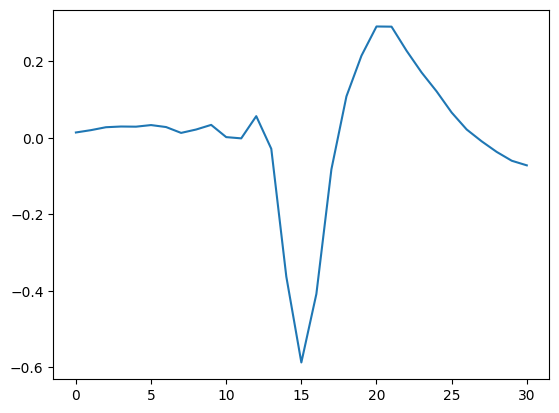

In [29]:
sns.lineplot(b['neuron_inf_waveform'][200].T)

<Axes: >

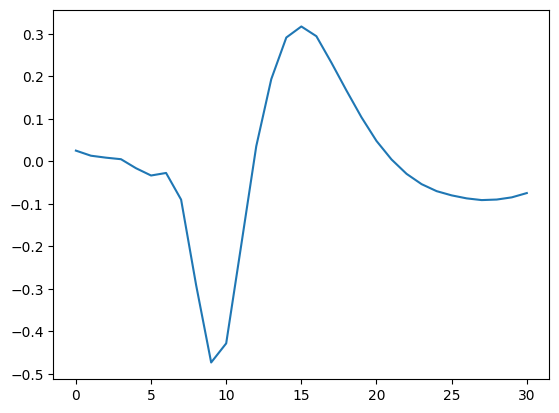

In [24]:
sns.lineplot(b['kmeans_cluster_waveform'][200].T)

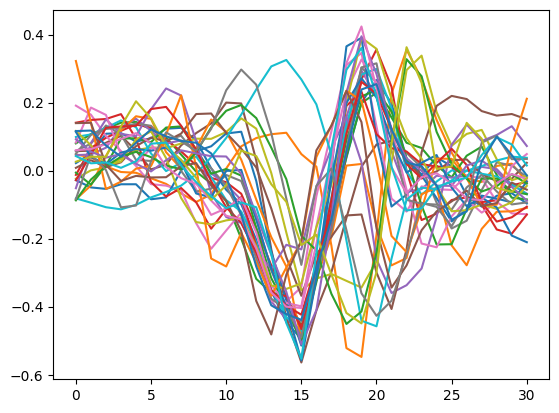

In [26]:
for i in range(31):
    sns.lineplot(b['kmeans_cluster_waveform'][i].T[::-1])

<Axes: >

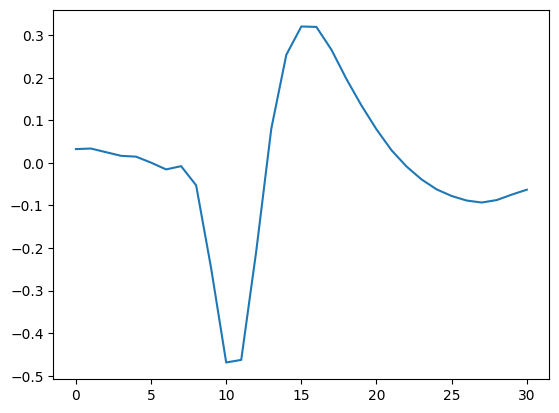

In [68]:
sns.lineplot(b['waveform'][7])

In [40]:
import pandas as pd

a = pd.read_csv("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/eval_results/022522/calibration_confusion_matrix.csv", index_col=0)

In [42]:
with open("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/021322/neuron_inf.pkl", 'rb') as f:
    b = pickle.load(f)

<Axes: >

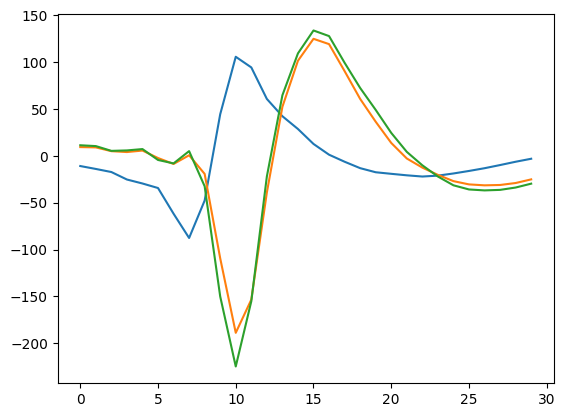

In [46]:
sns.lineplot(b['position_waveform'][17].T)
sns.lineplot(b['position_waveform'][18].T)
sns.lineplot(b['position_waveform'][16].T)

In [48]:
import numpy as np

In [63]:
import pickle 
with open("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/021322/neuron_inf.pkl", 'rb') as f:
    neuron_inf_021322 = pickle.load(f)

with open("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/022522/neuron_inf.pkl", 'rb') as f:
    neuron_inf_022522 = pickle.load(f)

In [67]:
neuron_021322 = neuron_inf_021322['Neuron'].values
neuron_022522 = neuron_inf_022522['Neuron'].values

In [185]:
matching_scores = np.load('/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/eval_results/022522/calibration_matching_scores.npy')

<Axes: ylabel='Count'>

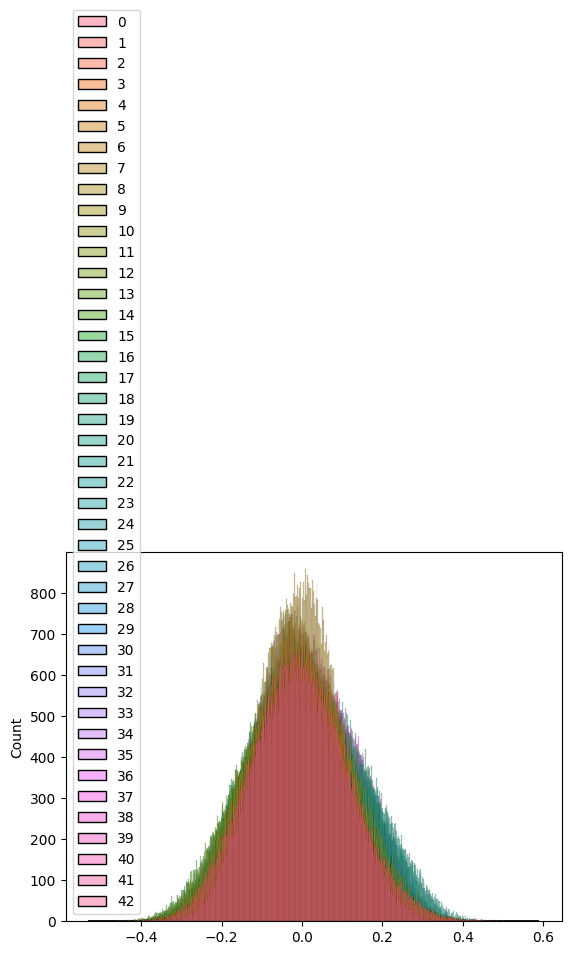

In [188]:
sns.histplot(matching_scores)

In [ ]:
matching_scores

np.float32(0.59001)

In [182]:
energy_scores = np.load("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/eval_results/022522/calibration_energy_scores.npy")
shape_scores = np.load("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/eval_results/022522/calibration_shape_scores.npy")
#gt_neuron = np.load("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/validation_results/gt_neuron_indices.npy")
# energy_scores[energy_scores < 0.6] = 0
# shape_scores[shape_scores < 0] = 0

# sum_scores = (energy_scores + shape_scores)

<Axes: ylabel='Count'>

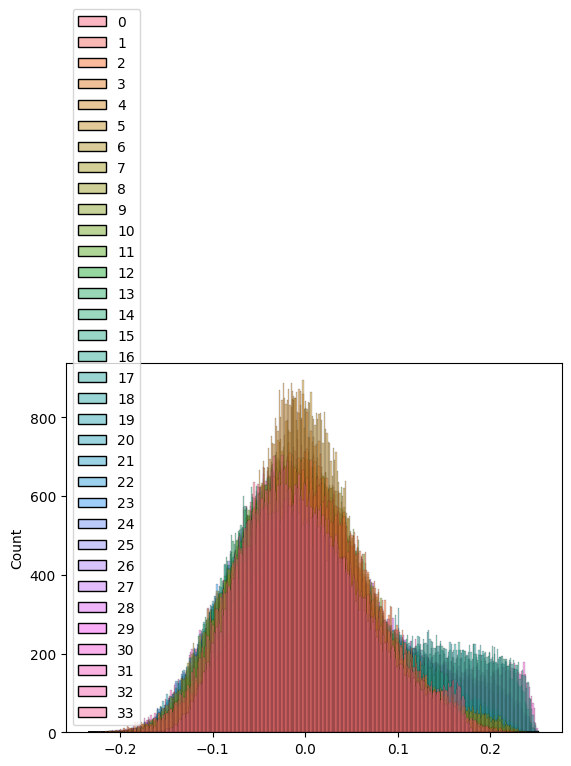

In [184]:
sns.histplot(shape_scores)

<Axes: ylabel='Count'>

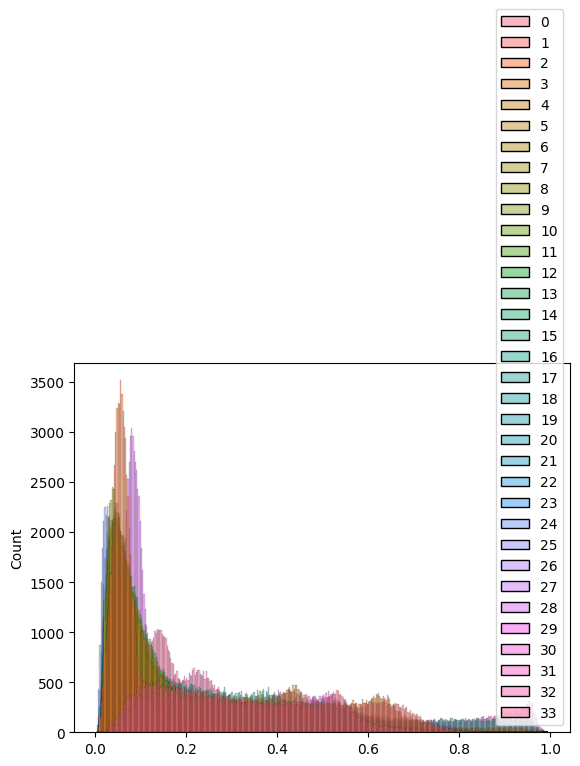

In [183]:
sns.histplot(energy_scores)

In [179]:
predict_neuron = []
for i in range(len(energy_scores)):
    if (np.sum(energy_scores[i, :]) == 0) or (np.sum(shape_scores[i, :]) == 0):
        #print(f'{neuron_1}: no match neuron in day1')
        predict_neuron.append('umatched')
    else:
        predict_neuron.append(neuron_021322[np.argmax(sum_scores[i, :])])
        # print(f'{neuron_1}: {neuron_022522[np.argmax(sum_scores[:, i])]}')
        # print(f'Matching score: {sum_scores[np.argmax(sum_scores[:, i]), i]}')

In [180]:
predict_neuron =pd.DataFrame(predict_neuron)

In [181]:
predict_neuron[0].value_counts()

0
Neuron_57    13722
Neuron_31    12226
umatched      7834
Neuron_2      5408
Neuron_70     2942
Neuron_69     2644
Neuron_55     2559
Neuron_8      2519
Neuron_11     1887
Neuron_34     1705
Neuron_71     1625
Neuron_1      1199
Neuron_48      256
Neuron_30      198
Neuron_40      188
Neuron_33      159
Neuron_43      105
Neuron_45      101
Neuron_44       72
Neuron_42       27
Neuron_22       26
Neuron_51       22
Neuron_53       16
Neuron_52       15
Neuron_17       13
Neuron_24       13
Neuron_21        8
Neuron_25        7
Neuron_28        3
Neuron_12        2
Neuron_16        2
Neuron_20        1
Neuron_27        1
Name: count, dtype: int64

In [71]:
for i in range(30):
    neuron_1 = neuron_022522[i]
    shape_neuron = neuron_021322[np.argmax(shape_scores[:, i])]
    shape_score = shape_scores[np.argmax(shape_scores[:, i]), i]
    energy_neuron = neuron_021322[np.argmax(energy_scores[:, i])]
    energy_score = energy_scores[np.argmax(energy_scores[:, i]), i]
    if shape_neuron == energy_neuron:
        print(f'Aligned: {neuron_1}: {shape_neuron}')
        print(f'shape score: {shape_score}, energy_score: {energy_score}')
    else:
        print(f'Aligned: {neuron_1}: shape_neuron: {shape_neuron}, energy_neuron: {energy_neuron}')
        print(f'shape score: {shape_score}, energy_score: {energy_score}')
    

Aligned: Neuron_3: shape_neuron: Neuron_71, energy_neuron: Neuron_8
shape score: 0.7028709650039673, energy_score: 0.9351299405097961
Aligned: Neuron_9: Neuron_1
shape score: 0.9198128581047058, energy_score: 0.9202905297279358
Aligned: Neuron_12: shape_neuron: Neuron_71, energy_neuron: Neuron_11
shape score: 0.9889423251152039, energy_score: 0.9859639406204224
Aligned: Neuron_13: shape_neuron: Neuron_71, energy_neuron: Neuron_11
shape score: 0.8952865600585938, energy_score: 0.9605555534362793
Aligned: Neuron_14: shape_neuron: Neuron_71, energy_neuron: Neuron_12
shape score: 0.7516701817512512, energy_score: 0.8474201560020447
Aligned: Neuron_15: shape_neuron: Neuron_17, energy_neuron: Neuron_24
shape score: 0.9498953223228455, energy_score: 0.9796949028968811
Aligned: Neuron_18: Neuron_22
shape score: 0.9586606025695801, energy_score: 0.9788053631782532
Aligned: Neuron_24: shape_neuron: Neuron_25, energy_neuron: Neuron_16
shape score: 0.8633242845535278, energy_score: 0.9894399642944

In [76]:
from scipy.stats import pearsonr

In [80]:
pearsonr(neuron_inf_021322['position_waveform'][23], neuron_inf_021322['position_waveform'][21])

PearsonRResult(statistic=np.float32(0.85429), pvalue=np.float64(1.9098652619475075e-09))

In [82]:
pearsonr(neuron_inf_021322['position_waveform'][23], neuron_inf_022522['position_waveform'][19])

PearsonRResult(statistic=np.float32(0.95722705), pvalue=np.float64(1.2927357263474016e-16))

In [83]:
pearsonr(neuron_inf_021322['position_waveform'][21], neuron_inf_022522['position_waveform'][19])

PearsonRResult(statistic=np.float32(0.94101727), pvalue=np.float64(1.0509766930805348e-14))

In [86]:
a = np.load("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/021322/shape_templates.npy")

<Axes: >

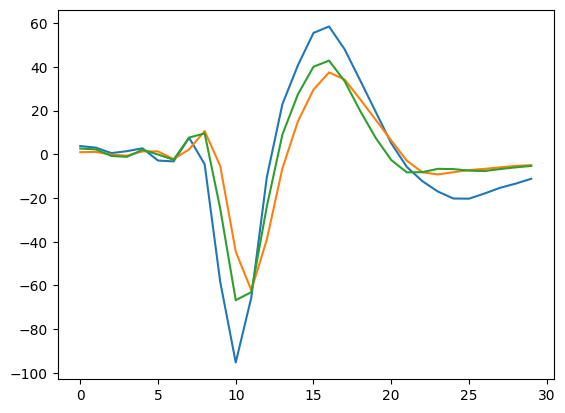

In [81]:
sns.lineplot(neuron_inf_021322['position_waveform'][23].T)
sns.lineplot(neuron_inf_021322['position_waveform'][21].T)
sns.lineplot(neuron_inf_022522['position_waveform'][19].T)

In [78]:
neuron_inf_022522

,Neuron,position_1,position_2,position_waveform,channel_id,cluster
0,Neuron_3,17.512636,35.752811,"[3.2526555, 2.7949586, 1.4568826, -0.48819783,...","[1, 3, 5, 7, 9, 11]",3
1,Neuron_9,22.432472,14.698872,"[2.737996, 3.5611422, 2.9425592, 3.0211866, 2....","[1, 3, 7, 9, 11]",9
2,Neuron_12,4.191727,70.332146,"[12.928641, 12.210501, 5.473361, 5.4525356, 9....","[1, 3, 5, 7, 9]",12
3,Neuron_13,5.375986,51.971687,"[-0.8723568, -0.45704898, -1.7247455, -1.56382...","[1, 3, 5, 7, 9]",13
4,Neuron_14,27.786940,63.619541,"[-0.07175204, -0.14420961, -0.9821535, -0.8999...","[3, 5, 7, 9, 11]",14
5,Neuron_15,183.531006,228.725189,"[6.4588623, 6.01891, 4.904146, 5.8878765, 5.01...","[13, 15, 19, 21, 23]",15
6,Neuron_18,181.585281,245.019363,"[0.40753877, 1.6416914, 0.80666125, 0.52655894...","[13, 15, 17, 19, 21, 23]",18
7,Neuron_24,166.596619,229.876434,"[4.1142144, 2.8329086, 0.55609006, -0.4578938,...","[13, 15, 17, 21, 23]",24
8,Neuron_28,183.083389,266.539154,"[0.7452692, 1.3823476, 1.2196943, 1.1886629, 1...","[15, 17, 19, 21, 23]",28
9,Neuron_29,163.431290,268.223114,"[4.420608, 4.2250323, 2.496528, 2.0893927, 3.6...","[13, 15, 17, 19, 21]",29


In [72]:
neuron_inf_021322

,Neuron,position_1,position_2,position_waveform,channel_id,cluster
0,Neuron_1,27.874662,23.113499,"[8.016708, 6.2269287, 3.7813566, 2.7285423, 1....","[1, 3, 7, 9, 11]","[1, 3]"
1,Neuron_2,13.890420,43.047367,"[9.143565, 7.4206758, 4.67621, 4.9696584, 4.17...","[1, 3, 5, 7, 9, 11]","[2, 5]"
2,Neuron_4,645.670410,12.851900,"[-3.8251324, 9.309573, 21.933748, 31.22607, 48...","[0, 2, 4, 8, 10]",4
3,Neuron_8,22.207985,43.975090,"[-9.164566, -10.343457, -14.859804, -19.693523...","[1, 3, 5, 7, 9, 11]",8
4,Neuron_11,6.436926,64.991539,"[-4.9541903, -2.8168643, -5.45192, -7.7048407,...","[1, 3, 5, 7, 9]",11
5,Neuron_12,32.563015,76.312965,"[-3.0296078, -2.794706, 1.8031144, -5.8711367,...","[3, 5, 7, 9, 11]",12
6,Neuron_16,166.812820,231.149261,"[-6.284642, -6.578104, -6.861333, -9.220764, -...","[13, 15, 17, 21, 23]",16
7,Neuron_17,186.887573,233.271393,"[8.1475725, 7.8094397, 7.2893057, 8.687758, 7....","[13, 15, 19, 21, 23]",17
8,Neuron_20,162.914886,224.947098,"[4.162447, 2.5723555, -0.07258303, 3.3985217, ...","[13, 15, 17, 21, 23]",20
9,Neuron_21,183.428192,247.307205,"[-7.3502107, -7.782247, -9.847653, -12.544176,...","[13, 15, 17, 19, 21, 23]",21


In [56]:
energy_scores[energy_scores < 0.4] = 0
shape_scores[shape_scores < 0] = 0

In [61]:
np.argmax(shape_scores, axis=1)

array([ 1,  2, 29, 24,  3, 24,  0,  5,  7,  0,  6,  5,  7,  9,  8, 13, 12,
       11, 10, 17, 20, 19, 22, 18, 18, 21, 21, 23, 29, 27, 25, 28, 29,  2])

In [68]:
np.argmax(energy_scores, axis=1)

array([ 1,  0,  0,  0,  2,  4,  7,  6,  7,  6,  6,  5,  7,  9,  8, 13, 12,
       10, 10, 17, 20, 19, 16, 16, 18, 21, 21, 23,  0, 27, 25, 28, 29,  2])

<Axes: >

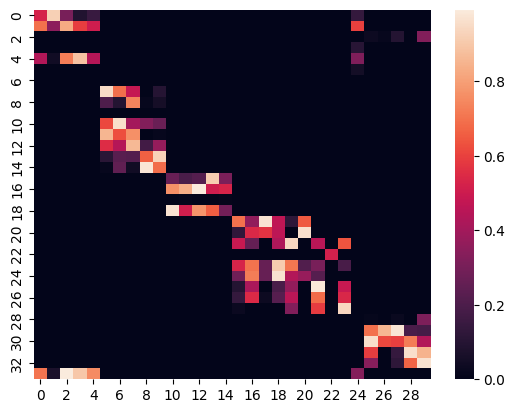

In [57]:
sns.heatmap(shape_scores)

<Axes: >

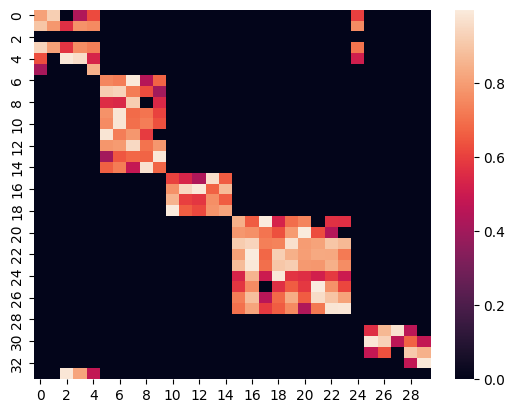

In [58]:
sns.heatmap(energy_scores)